In [1]:
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn import preprocessing

### Functions for Calculation Centralities

In [2]:
# Weighted Closeness Centrality
def weighted_closeness(G):
    nodes = list(G.nodes())
    closeness = []
    for i in range(0, len(nodes)):
        close = []
        dist_ij = 0
        for j in range(0, len(nodes)):
            if(nodes[i] == nodes[j]):
                    continue
            else:
                wt , s_path = nx.bidirectional_dijkstra(G, source=nodes[i], target=nodes[j], weight='weight')
                dist_ij = dist_ij + wt
        closeness_i = 1 / dist_ij
        close.append(nodes[i])
        close.append(closeness_i)
        closeness.append(close)
    return closeness

# Weighted Betweenness Centrality
def weighted_betweenness(G):
    nodes = list(G.nodes())
    betweenness = []
    for n in range(0, len(nodes)):
        bett = []
        dist_n = 0
        dist_v = 0
        for s in range(0, len(nodes)):
            for t in range(s+1, len(nodes)):
                if(nodes[n] == nodes[s] or nodes[n] == nodes[t] or nodes[s] == nodes[t]):
                    continue
                else:
                    wt , s_path = nx.bidirectional_dijkstra(G, source=nodes[s], target=nodes[t], weight='weight')
                    if(nodes[n] in s_path):
                        dist_n = dist_n + wt
                    dist_v = dist_v + wt
        betweenness_n = dist_n / dist_v
        bett.append(nodes[n])
        bett.append(betweenness_n)
        betweenness.append(bett)
    return betweenness

# Weighted Edge Contribution Factor
def weighted_ECF(G, W):
    nodes = list(G.nodes())
    ecf = []
    for i in range(0, len(nodes)):
        ecf_ = []
        w_ij = 0
        w_jk = 0
        neighbours_i = list(G.neighbors(nodes[i]))
        for n in range(0, len(neighbours_i)):
            w_ = G.get_edge_data(nodes[i], neighbours_i[n])
            val = w_['weight']
            w_ij = w_ij + val
        nbunch = neighbours_i
        common_neighbours = G.edges(nbunch, data=True)
        common_neighbours = list(common_neighbours)
        for j in range(0, len(common_neighbours)):
            if((common_neighbours[j][0] == nodes[i]) or (common_neighbours[j][1] == nodes[i])):
                continue
            elif(((common_neighbours[j][0] in neighbours_i) == False) or ((common_neighbours[j][1] in neighbours_i) == False )):
                continue
            else:
                w_ = G.get_edge_data(common_neighbours[j][0], common_neighbours[j][1])
                val = w_['weight']
                w_jk = w_jk + val            
            
        w_ecf = (w_ij + w_jk) / W
        ecf_.append(nodes[i])
        ecf_.append(w_ecf)
        ecf.append(ecf_)
    return ecf

def degree(G,W):
    nodes = list(G.nodes())
    w_degree = []
    for i in range(0, len(nodes)):
        deg = []
        nd = nodes[i]
        m_dg = modi_deg(G,nd,W)
        deg.append(nd)
        deg.append(m_dg)
        w_degree.append(deg)
    return w_degree

# New One
def modi_deg(G,i,W_):
    d_i = G.degree(i, weight='weight')
    m_deg = (d_i/W_)/2
    return m_deg

def edge_weighted(G,i):
    all_edges = []
    nbr_i = list(G.neighbors(i))
    for n in range(0,len(nbr_i)):
        j = nbr_i[n]
        adjacent_edges_j = list(G.edges(j))
        all_edges.append(adjacent_edges_j)
    
    all_edges = list(all_edges)
    al_edges = []
    for e in range(0,len(all_edges)):
        al_edges = al_edges + all_edges[e]
    
    rmv_edges = []
    for e_ in range(0, len(al_edges)):
        ed = al_edges[e_]
        if((ed[0] == i) or (ed[1] == i)):
            rmv_edges.append(ed)

    for ed in range(0, len(rmv_edges)):
        rmv_e = rmv_edges[ed]
        al_edges.remove(rmv_e)
        
    if(len(al_edges) == 0):
        return 0
    else:
        refined_edges = list({*map(tuple, map(sorted, al_edges))})
    
        ew_i = 0
        for a in range(0,len(refined_edges)):
            ii = refined_edges[a][0]
            jj = refined_edges[a][1]
            w_jk = G.get_edge_data(ii, jj)
            val = w_jk['weight']
            ew_i = ew_i + val
    
        return ew_i

def weight_of_a_node(G,i,W_1):
    m_deg = modi_deg(G,i,W_1)
    deg_i = G.degree(i, weight='weight')
    edge_wt = edge_weighted(G,i)
    value = (deg_i + edge_wt)/W_1
    weight_value = value * m_deg
    return weight_value


def weighted_cness(G, W):
    nodes = list(G.nodes())
    w_closeness = []
    for i in range(0, len(nodes)):
        closeness = []
        nd = nodes[i]
        weight = weight_of_a_node(G,nd,W)
        closeness.append(nd)
        closeness.append(weight)
        w_closeness.append(closeness)
    return w_closeness
# End of New One


# Total Edge Weight of a Graph
def total_weight_of_G(G):
    edge_weights = list(G.edges.data('weight'))
    W_ = 0
    for e in range(len(edge_weights)):
        w = edge_weights[e][2]
        W_ += w
    return W_


def convert_to_list_value(lst,index):
    l = []
    for i in range(0, len(lst)):
        val = lst[i][index]
        l.append(val)
    return l

### Loading Dataset and Create the Network and its Visualization

### s_s_1

Name: 
Type: Graph
Number of nodes: 5
Number of edges: 5
Average degree:   2.0000


C:\ProgramData\Anaconda3\lib\site-packages\networkx\drawing\nx_pylab.py:611: MatplotlibDeprecationWarning: isinstance(..., numbers.Number)
  if cb.is_numlike(alpha):


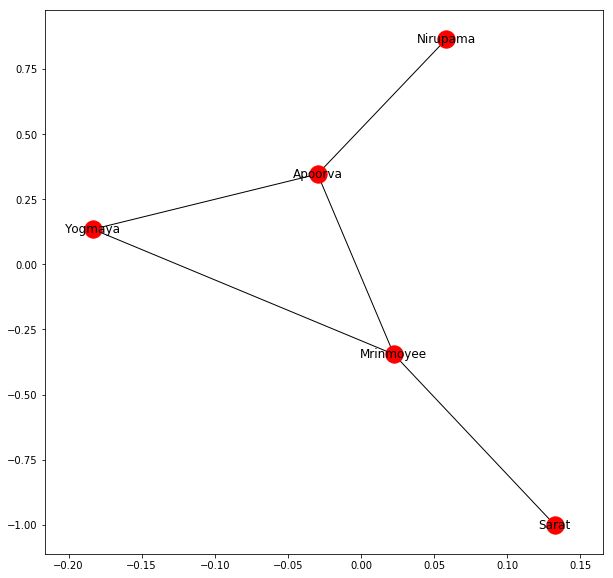

       Nodes  Degree       ECF       NCF
0    Apoorva    11.0  0.923077  0.423077
1    Yogmaya     9.0  0.769231  0.346154
2   Nirupama     2.0  0.153846  0.065089
3  Mrinmoyee     3.0  0.846154  0.115385
4      Sarat     1.0  0.076923  0.008876
     Degree       ECF       NCF
0  0.748455  0.623850  0.752090
1  0.612372  0.519875  0.615346
2  0.136083  0.103975  0.115706
3  0.204124  0.571863  0.205115
4  0.068041  0.051988  0.015778


In [3]:
ss_1 = nx.read_weighted_edgelist('s_s_1.txt', delimiter=',')
print(nx.info(ss_1))

plt.figure(figsize = (10,10))
nx.draw_networkx(ss_1)
plt.show()

#Weighted Centralities
w_deg = ss_1.degree(weight='weight') # Degree
w_deg = list(w_deg)

total_edge_weight = total_weight_of_G(ss_1)  #ECF
w_ecf = weighted_ECF(ss_1, total_edge_weight)

total_edge_weight = total_weight_of_G(ss_1) #NCF
w_ncf = weighted_cness(ss_1,total_edge_weight)


df = pd.DataFrame()
df["Nodes"] = convert_to_list_value(w_deg,0)
df["Degree"] = convert_to_list_value(w_deg,1)
df["ECF"] = convert_to_list_value(w_ecf,1)
df["NCF"] = convert_to_list_value(w_ncf,1)

print(df)

degree_c = np.array(df['Degree'])
ecf_c = np.array(df['ECF'])
ncf_c = np.array(df['NCF'])

normalized_deg = preprocessing.normalize([degree_c])

normalized_ecf = preprocessing.normalize([ecf_c])

normalized_ncf = preprocessing.normalize([ncf_c])

df_2 = pd.DataFrame()
df_2["Degree"] = np.concatenate(normalized_deg).ravel()
df_2["ECF"] = np.concatenate(normalized_ecf).ravel()
df_2["NCF"] = np.concatenate(normalized_ncf).ravel()

print(df_2)

In [4]:
df_3 = df_2
df_3.round(decimals = 3)

,Degree,ECF,NCF
0,0.748,0.624,0.752
1,0.612,0.520,0.615
2,0.136,0.104,0.116
3,0.204,0.572,0.205
4,0.068,0.052,0.016


Text(0, 0.5, 'Values')

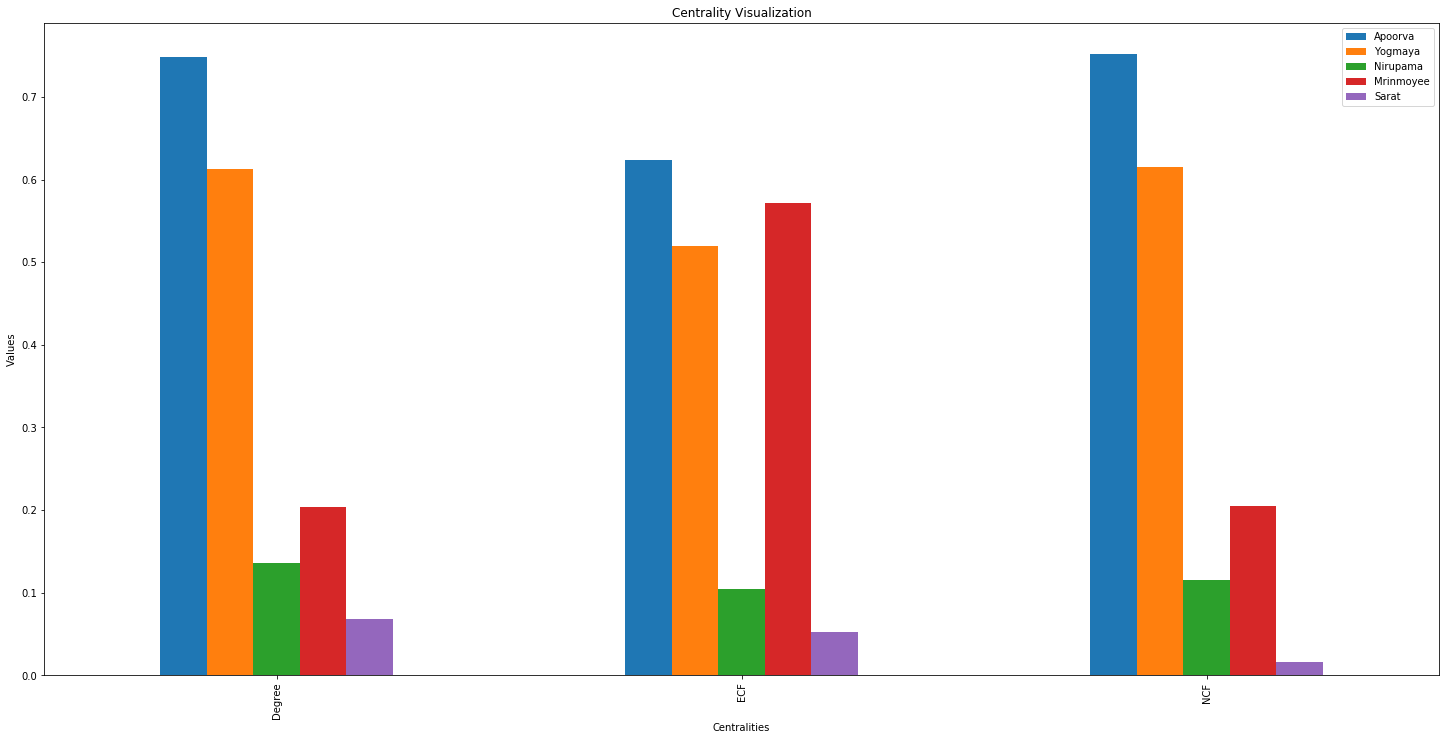

In [5]:
plotdata = pd.DataFrame({

    "Apoorva":list(df_2.loc[0]),
    "Yogmaya":list(df_2.loc[1]),

    "Nirupama":list(df_2.loc[2]),

    "Mrinmoyee":list(df_2.loc[3]),
    
    "Sarat":list(df_2.loc[4])},

    index=["Degree", "ECF", "NCF"])

plotdata.plot(kind="bar",figsize=(25, 12))

plt.title("Centrality Visualization")

plt.xlabel("Centralities")

plt.ylabel("Values")

Text(0, 0.5, 'Values')

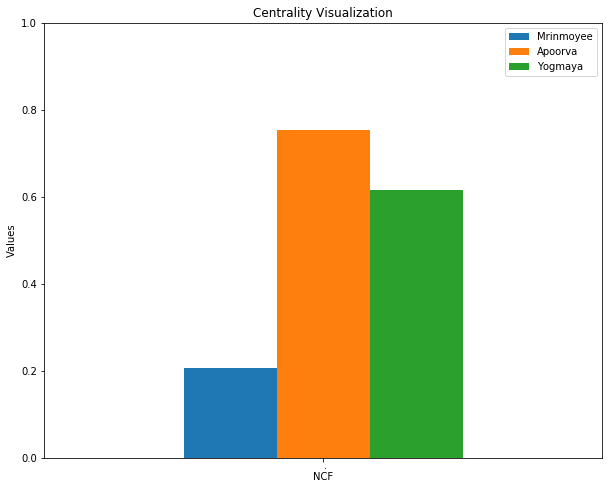

In [6]:
plotdata = pd.DataFrame({

    "Mrinmoyee":df_2.loc[3][2],
    "Apoorva":df_2.loc[0][2],
    "Yogmaya":df_2.loc[1][2]},

    index=["."])

plotdata.plot(kind="bar",figsize=(10, 8), ylim=[0,1])

plt.title("Centrality Visualization")

plt.xlabel("NCF")

plt.ylabel("Values")

### s_s_2

Name: 
Type: Graph
Number of nodes: 9
Number of edges: 11
Average degree:   2.4444


C:\ProgramData\Anaconda3\lib\site-packages\networkx\drawing\nx_pylab.py:611: MatplotlibDeprecationWarning: isinstance(..., numbers.Number)
  if cb.is_numlike(alpha):


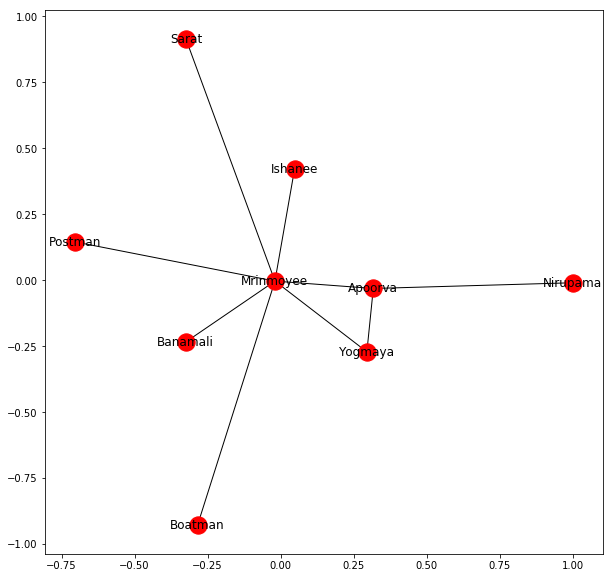

       Nodes  Degree       ECF       NCF
0    Apoorva    29.0  0.705882  0.289889
1    Yogmaya    14.0  0.666667  0.137255
2  Mrinmoyee    42.0  0.960784  0.435986
3    Ishanee     5.0  0.156863  0.037486
4    Postman     2.0  0.098039  0.014994
5    Boatman     1.0  0.078431  0.007497
6   Banamali     6.0  0.176471  0.044983
7      Sarat     1.0  0.078431  0.007497
8   Nirupama     2.0  0.058824  0.010765
     Degree       ECF       NCF
0  0.541135  0.505889  0.532071
1  0.261238  0.477785  0.251922
2  0.783713  0.688572  0.800224
3  0.093299  0.112420  0.068802
4  0.037320  0.070262  0.027521
5  0.018660  0.056210  0.013760
6  0.111959  0.126472  0.082563
7  0.018660  0.056210  0.013760
8  0.037320  0.042157  0.019759


In [7]:
ss_2 = nx.read_weighted_edgelist('s_s_2.txt', delimiter=',')
print(nx.info(ss_2))

plt.figure(figsize = (10,10))
nx.draw_networkx(ss_2)
plt.show()

#Weighted Centralities
w_deg = ss_2.degree(weight='weight') # Degree
w_deg = list(w_deg)

total_edge_weight = total_weight_of_G(ss_2)  #ECF
w_ecf = weighted_ECF(ss_2, total_edge_weight)

total_edge_weight = total_weight_of_G(ss_2) #NCF
w_ncf = weighted_cness(ss_2,total_edge_weight)


df = pd.DataFrame()
df["Nodes"] = convert_to_list_value(w_deg,0)
df["Degree"] = convert_to_list_value(w_deg,1)
df["ECF"] = convert_to_list_value(w_ecf,1)
df["NCF"] = convert_to_list_value(w_ncf,1)

print(df)

degree_c = np.array(df['Degree'])
ecf_c = np.array(df['ECF'])
ncf_c = np.array(df['NCF'])

normalized_deg = preprocessing.normalize([degree_c])

normalized_ecf = preprocessing.normalize([ecf_c])

normalized_ncf = preprocessing.normalize([ncf_c])

df_2 = pd.DataFrame()
df_2["Degree"] = np.concatenate(normalized_deg).ravel()
df_2["ECF"] = np.concatenate(normalized_ecf).ravel()
df_2["NCF"] = np.concatenate(normalized_ncf).ravel()

print(df_2)

In [8]:
df_3 = df_2
df_3.round(decimals = 3)

,Degree,ECF,NCF
0,0.541,0.506,0.532
1,0.261,0.478,0.252
2,0.784,0.689,0.800
3,0.093,0.112,0.069
4,0.037,0.070,0.028
5,0.019,0.056,0.014
6,0.112,0.126,0.083
7,0.019,0.056,0.014
8,0.037,0.042,0.020


Text(0, 0.5, 'Values')

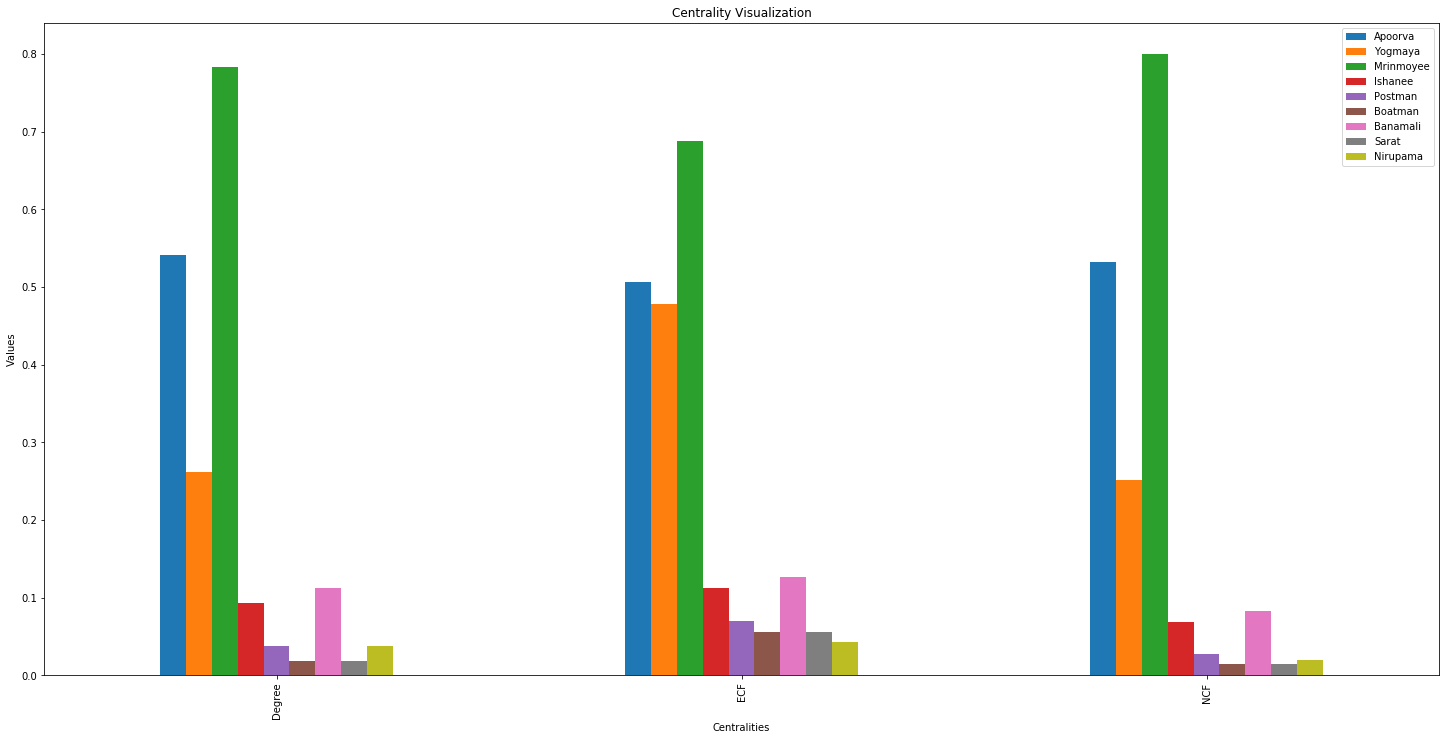

In [9]:
plotdata = pd.DataFrame({

    "Apoorva":list(df_2.loc[0]),
    "Yogmaya":list(df_2.loc[1]),

    "Mrinmoyee":list(df_2.loc[2]),

    "Ishanee":list(df_2.loc[3]),
    
    "Postman":list(df_2.loc[4]),
    "Boatman":list(df_2.loc[5]),
    "Banamali":list(df_2.loc[6]),
    "Sarat":list(df_2.loc[7]),
    "Nirupama":list(df_2.loc[8])},

    index=["Degree", "ECF", "NCF"])

plotdata.plot(kind="bar",figsize=(25, 12))

plt.title("Centrality Visualization")

plt.xlabel("Centralities")

plt.ylabel("Values")

Text(0, 0.5, 'Values')

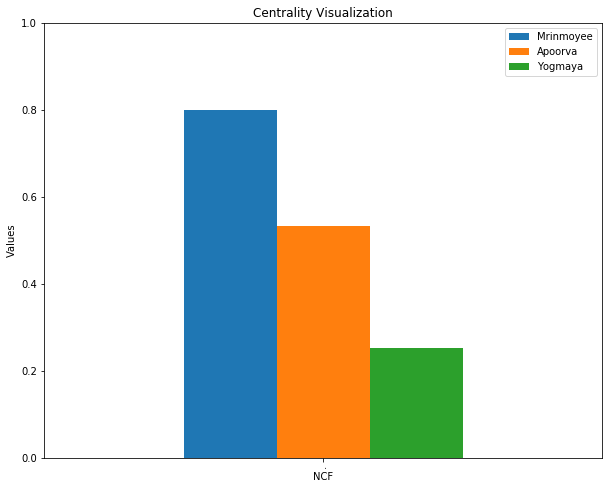

In [10]:
plotdata = pd.DataFrame({

    "Mrinmoyee":df_2.loc[2][2],
    "Apoorva":df_2.loc[0][2],
    "Yogmaya":df_2.loc[1][2]},

    index=["."])

plotdata.plot(kind="bar",figsize=(10, 8), ylim=[0,1])

plt.title("Centrality Visualization")

plt.xlabel("NCF")

plt.ylabel("Values")

### s_s_3

Name: 
Type: Graph
Number of nodes: 9
Number of edges: 11
Average degree:   2.4444


C:\ProgramData\Anaconda3\lib\site-packages\networkx\drawing\nx_pylab.py:611: MatplotlibDeprecationWarning: isinstance(..., numbers.Number)
  if cb.is_numlike(alpha):


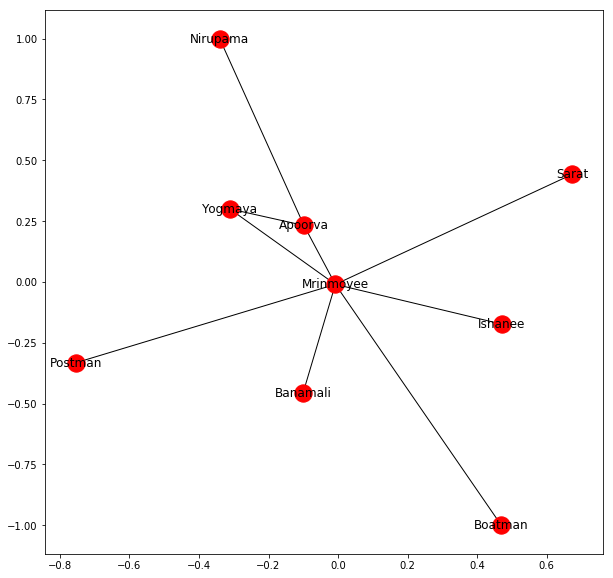

       Nodes  Degree       ECF       NCF
0  Mrinmoyee    73.0  0.976471  0.469827
1    Apoorva    57.0  0.811765  0.339239
2    Yogmaya    22.0  0.788235  0.129412
3    Ishanee     5.0  0.152941  0.022491
4    Postman     2.0  0.117647  0.008997
5    Boatman     1.0  0.105882  0.004498
6   Banamali     6.0  0.164706  0.026990
7      Sarat     2.0  0.117647  0.008997
8   Nirupama     2.0  0.035294  0.007751
     Degree       ECF       NCF
0  0.763739  0.640473  0.789604
1  0.596344  0.532442  0.570134
2  0.230168  0.517009  0.217493
3  0.052311  0.100315  0.037800
4  0.020924  0.077165  0.015120
5  0.010462  0.069449  0.007560
6  0.062773  0.108032  0.045359
7  0.020924  0.077165  0.015120
8  0.020924  0.023150  0.013026


In [11]:
ss_3 = nx.read_weighted_edgelist('s_s_3.txt', delimiter=',')
print(nx.info(ss_3))

plt.figure(figsize = (10,10))
nx.draw_networkx(ss_3)
plt.show()

#Weighted Centralities
w_deg = ss_3.degree(weight='weight') # Degree
w_deg = list(w_deg)

total_edge_weight = total_weight_of_G(ss_3)  #ECF
w_ecf = weighted_ECF(ss_3, total_edge_weight)

total_edge_weight = total_weight_of_G(ss_3) #NCF
w_ncf = weighted_cness(ss_3,total_edge_weight)


df = pd.DataFrame()
df["Nodes"] = convert_to_list_value(w_deg,0)
df["Degree"] = convert_to_list_value(w_deg,1)
df["ECF"] = convert_to_list_value(w_ecf,1)
df["NCF"] = convert_to_list_value(w_ncf,1)

print(df)

degree_c = np.array(df['Degree'])
ecf_c = np.array(df['ECF'])
ncf_c = np.array(df['NCF'])

normalized_deg = preprocessing.normalize([degree_c])

normalized_ecf = preprocessing.normalize([ecf_c])

normalized_ncf = preprocessing.normalize([ncf_c])

df_2 = pd.DataFrame()
df_2["Degree"] = np.concatenate(normalized_deg).ravel()
df_2["ECF"] = np.concatenate(normalized_ecf).ravel()
df_2["NCF"] = np.concatenate(normalized_ncf).ravel()

print(df_2)

In [12]:
df_3 = df_2
df_3.round(decimals = 3)

,Degree,ECF,NCF
0,0.764,0.640,0.790
1,0.596,0.532,0.570
2,0.230,0.517,0.217
3,0.052,0.100,0.038
4,0.021,0.077,0.015
5,0.010,0.069,0.008
6,0.063,0.108,0.045
7,0.021,0.077,0.015
8,0.021,0.023,0.013


Text(0, 0.5, 'Values')

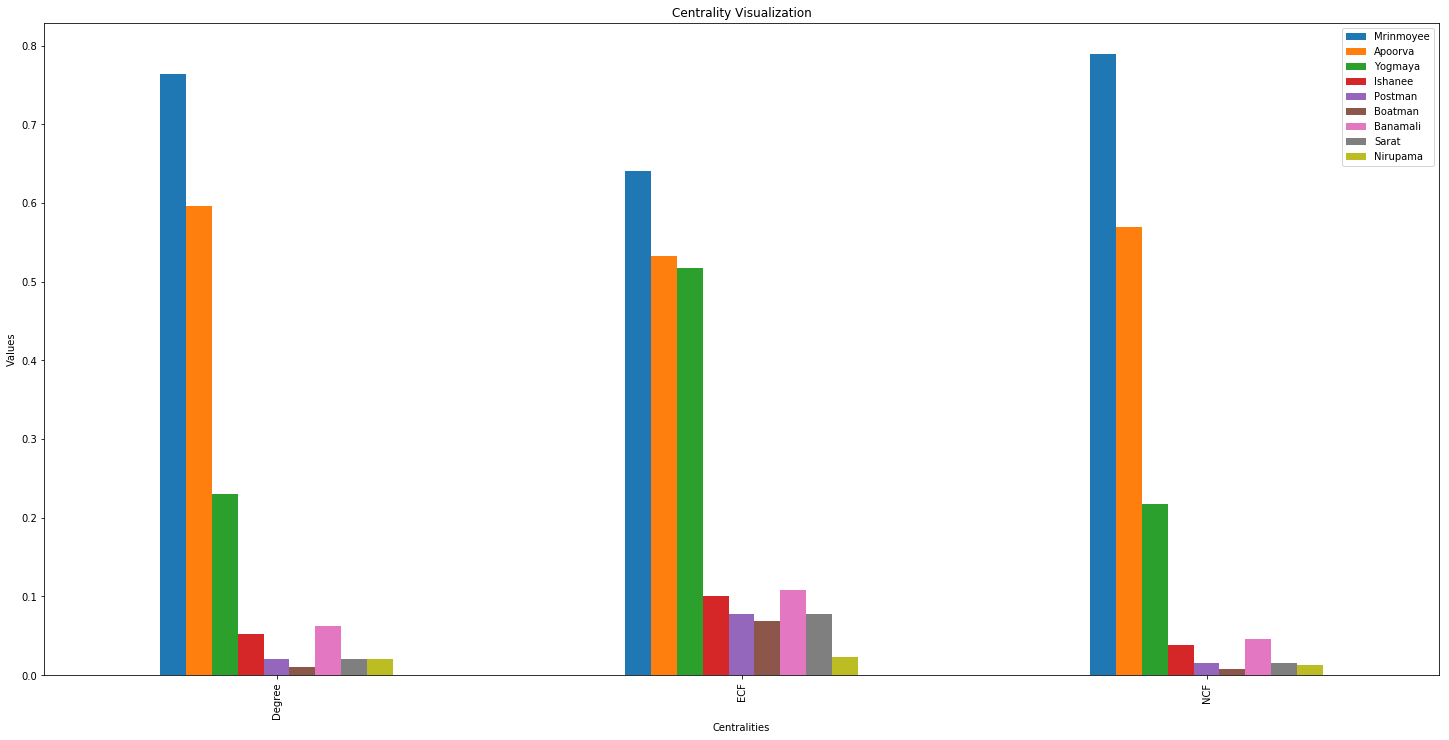

In [13]:
plotdata = pd.DataFrame({

    "Mrinmoyee":list(df_2.loc[0]),
    "Apoorva":list(df_2.loc[1]),

    "Yogmaya":list(df_2.loc[2]),

    "Ishanee":list(df_2.loc[3]),
    
    "Postman":list(df_2.loc[4]),
    "Boatman":list(df_2.loc[5]),
    "Banamali":list(df_2.loc[6]),
    "Sarat":list(df_2.loc[7]),
    "Nirupama":list(df_2.loc[8])},

    index=["Degree", "ECF", "NCF"])

plotdata.plot(kind="bar",figsize=(25, 12))

plt.title("Centrality Visualization")

plt.xlabel("Centralities")

plt.ylabel("Values")

Text(0, 0.5, 'Values')

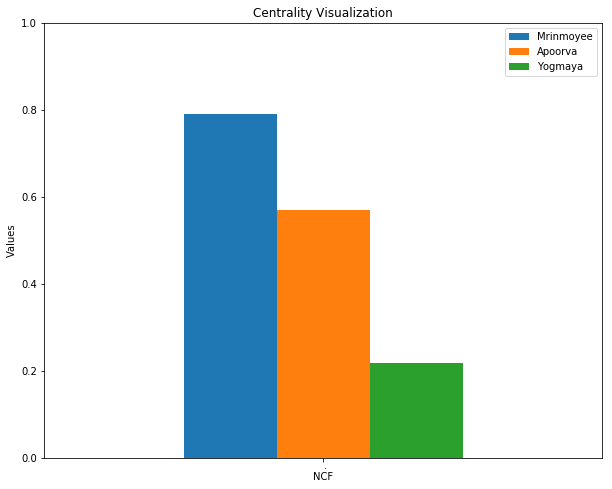

In [14]:
plotdata = pd.DataFrame({

    "Mrinmoyee":df_2.loc[0][2],
    "Apoorva":df_2.loc[1][2],
    "Yogmaya":df_2.loc[2][2]},

    index=["."])

plotdata.plot(kind="bar",figsize=(10, 8), ylim=[0,1])

plt.title("Centrality Visualization")

plt.xlabel("NCF")

plt.ylabel("Values")

### s_s_4

Name: 
Type: Graph
Number of nodes: 12
Number of edges: 15
Average degree:   2.5000


C:\ProgramData\Anaconda3\lib\site-packages\networkx\drawing\nx_pylab.py:611: MatplotlibDeprecationWarning: isinstance(..., numbers.Number)
  if cb.is_numlike(alpha):


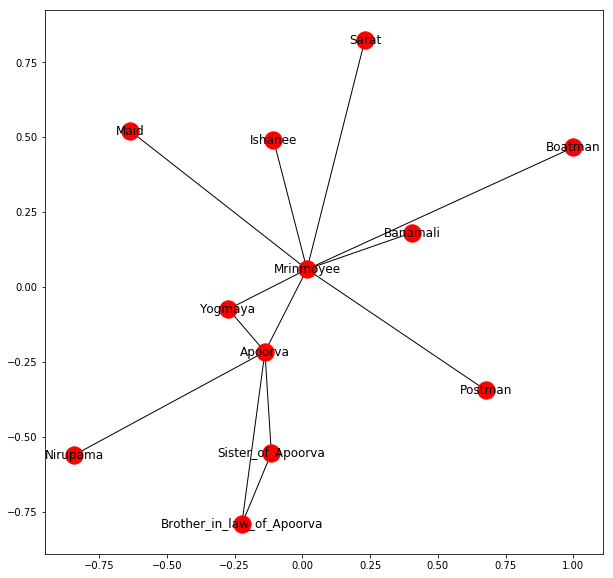

                        Nodes  Degree       ECF       NCF
0                   Mrinmoyee    77.0  0.821429  0.356027
1                     Apoorva    76.0  0.839286  0.342315
2                     Yogmaya    29.0  0.660714  0.124841
3                     Ishanee     5.0  0.116071  0.013752
4                     Postman     2.0  0.089286  0.005501
5                     Boatman     1.0  0.080357  0.002750
6                    Banamali     6.0  0.125000  0.016502
7                       Sarat     2.0  0.089286  0.005501
8                    Nirupama     2.0  0.026786  0.005979
9           Sister_of_Apoorva    14.0  0.169643  0.044085
10  Brother_in_law_of_Apoorva     8.0  0.169643  0.025191
11                       Maid     2.0  0.089286  0.005501
      Degree       ECF       NCF
0   0.678368  0.590752  0.694637
1   0.669558  0.603594  0.667885
2   0.255489  0.475170  0.243574
3   0.044050  0.083476  0.026830
4   0.017620  0.064212  0.010732
5   0.008810  0.057791  0.005366
6   0.052860  0

In [15]:
ss_4 = nx.read_weighted_edgelist('s_s_4.txt', delimiter=',')
print(nx.info(ss_4))

plt.figure(figsize = (10,10))
nx.draw_networkx(ss_4)
plt.show()

#Weighted Centralities
w_deg = ss_4.degree(weight='weight') # Degree
w_deg = list(w_deg)

total_edge_weight = total_weight_of_G(ss_4)  #ECF
w_ecf = weighted_ECF(ss_4, total_edge_weight)

total_edge_weight = total_weight_of_G(ss_4) #NCF
w_ncf = weighted_cness(ss_4,total_edge_weight)


df = pd.DataFrame()
df["Nodes"] = convert_to_list_value(w_deg,0)
df["Degree"] = convert_to_list_value(w_deg,1)
df["ECF"] = convert_to_list_value(w_ecf,1)
df["NCF"] = convert_to_list_value(w_ncf,1)

print(df)

degree_c = np.array(df['Degree'])
ecf_c = np.array(df['ECF'])
ncf_c = np.array(df['NCF'])

normalized_deg = preprocessing.normalize([degree_c])

normalized_ecf = preprocessing.normalize([ecf_c])

normalized_ncf = preprocessing.normalize([ncf_c])

df_2 = pd.DataFrame()
df_2["Degree"] = np.concatenate(normalized_deg).ravel()
df_2["ECF"] = np.concatenate(normalized_ecf).ravel()
df_2["NCF"] = np.concatenate(normalized_ncf).ravel()

print(df_2)

In [16]:
df_3 = df_2
df_3.round(decimals = 3)

,Degree,ECF,NCF
0,0.678,0.591,0.695
1,0.670,0.604,0.668
2,0.255,0.475,0.244
3,0.044,0.083,0.027
4,0.018,0.064,0.011
5,0.009,0.058,0.005
6,0.053,0.090,0.032
7,0.018,0.064,0.011
8,0.018,0.019,0.012
9,0.123,0.122,0.086


Text(0, 0.5, 'Values')

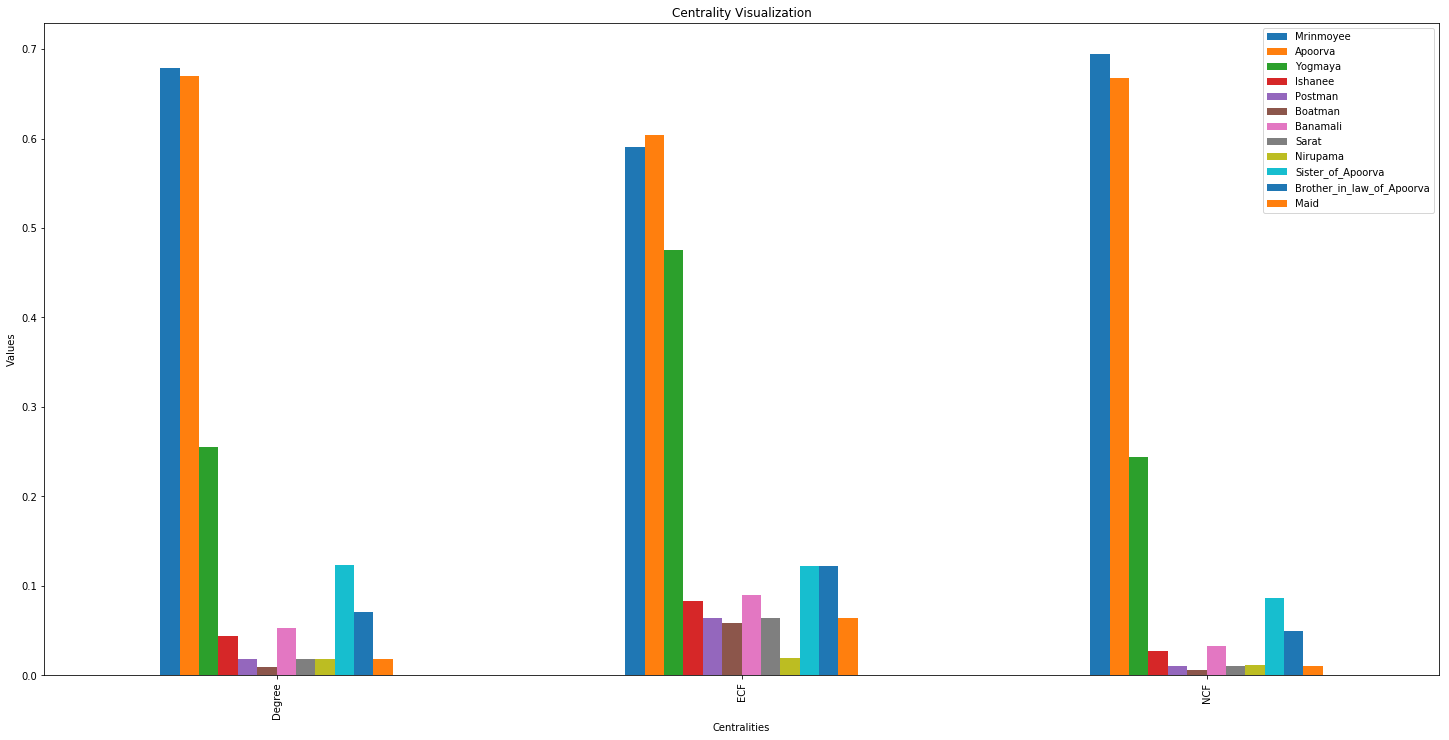

In [17]:
plotdata = pd.DataFrame({

    "Mrinmoyee":list(df_2.loc[0]),
    "Apoorva":list(df_2.loc[1]),

    "Yogmaya":list(df_2.loc[2]),

    "Ishanee":list(df_2.loc[3]),
    
    "Postman":list(df_2.loc[4]),
    "Boatman":list(df_2.loc[5]),
    "Banamali":list(df_2.loc[6]),
    "Sarat":list(df_2.loc[7]),
    "Nirupama":list(df_2.loc[8]),
    "Sister_of_Apoorva":list(df_2.loc[9]),
    "Brother_in_law_of_Apoorva":list(df_2.loc[10]),
    "Maid":list(df_2.loc[11])},

    index=["Degree", "ECF", "NCF"])

plotdata.plot(kind="bar",figsize=(25, 12))

plt.title("Centrality Visualization")

plt.xlabel("Centralities")

plt.ylabel("Values")

Text(0, 0.5, 'Values')

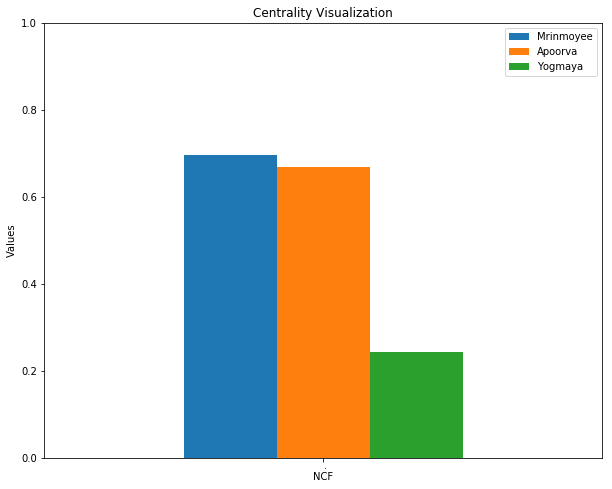

In [18]:
plotdata = pd.DataFrame({

    "Mrinmoyee":df_2.loc[0][2],
    "Apoorva":df_2.loc[1][2],
    "Yogmaya":df_2.loc[2][2]},

    index=["."])

plotdata.plot(kind="bar",figsize=(10, 8), ylim=[0,1])

plt.title("Centrality Visualization")

plt.xlabel("NCF")

plt.ylabel("Values")

In [19]:
# Let's create a Dataframe using lists
timestamp = ['t1', 't2', 't3', 't4']

apoorva = [0.752090,0.532071,0.570134,0.667885]

yogmaya = [0.615346,0.251922,0.217493,0.243574]
mrinmoyee = [0.205115,0.800224,0.789604,0.694637]

# Now, create a pandas dataframe using above lists
df_pop_density = pd.DataFrame(
    {'Timestamp' : timestamp, 'Apoorva' : apoorva,'Yogmaya' : yogmaya, 'Mrinmoyee' : mrinmoyee})

df_pop_density

,Timestamp,Apoorva,Yogmaya,Mrinmoyee
0,t1,0.752090,0.615346,0.205115
1,t2,0.532071,0.251922,0.800224
2,t3,0.570134,0.217493,0.789604
3,t4,0.667885,0.243574,0.694637


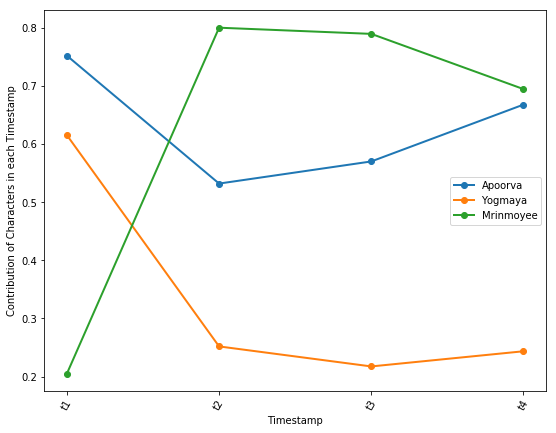

In [20]:
# Creating figure and axis objects using subplots()
fig, ax = plt.subplots(figsize=[9, 7])

ax.plot(df_pop_density['Timestamp'], df_pop_density['Apoorva'], marker='o', linewidth=2, label='Apoorva')
ax.plot(df_pop_density['Timestamp'], df_pop_density['Yogmaya'], marker='o', linewidth=2, label='Yogmaya')
ax.plot(df_pop_density['Timestamp'], df_pop_density['Mrinmoyee'], marker='o', linewidth=2, label='Mrinmoyee')
plt.xticks(rotation=60)
ax.set_xlabel('Timestamp')
ax.set_ylabel('Contribution of Characters in each Timestamp')
plt.legend()
plt.show()

In [12]:
# Reevaluate the remaining part

In [62]:
# Let's create a Dataframe using lists
timestamp = ['t1', 't2', 't3', 't4']

apoorva_yogmaya = [0.8181818181818182,1.4729064039408866,1.6794258373205742,1.3652450090744102]

apoorva_mrinmoyee = [0.5454545454545454,1.379310344827586,2.0050125313283207,1.4123376623376624]

# Now, create a pandas dataframe using above lists
df_pop_density = pd.DataFrame(
    {'Timestamp' : timestamp, 'Correlation_With_Yogmaya' : apoorva_yogmaya, 'Correlation_With_Mrinmoyee' : apoorva_mrinmoyee})

df_pop_density

,Timestamp,Correlation_With_Yogmaya,Correlation_With_Mrinmoyee
0,t1,0.818182,0.545455
1,t2,1.472906,1.379310
2,t3,1.679426,2.005013
3,t4,1.365245,1.412338


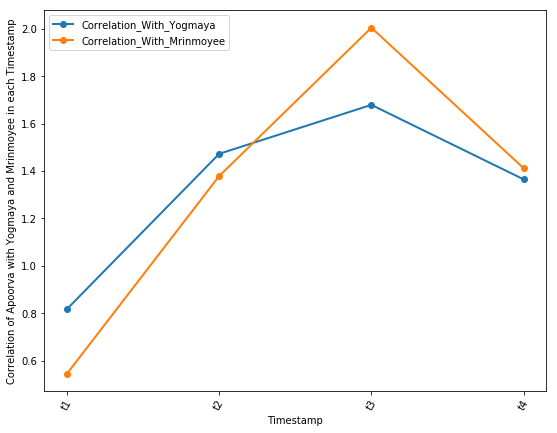

In [63]:
# Creating figure and axis objects using subplots()
fig, ax = plt.subplots(figsize=[9, 7])

ax.plot(df_pop_density['Timestamp'], df_pop_density['Correlation_With_Yogmaya'], marker='o', linewidth=2, label='Correlation_With_Yogmaya')
ax.plot(df_pop_density['Timestamp'], df_pop_density['Correlation_With_Mrinmoyee'], marker='o', linewidth=2, label='Correlation_With_Mrinmoyee')
plt.xticks(rotation=60)
ax.set_xlabel('Timestamp')
ax.set_ylabel('Correlation of Apoorva with Yogmaya and Mrinmoyee in each Timestamp')
plt.legend()
plt.show()